# Библиотеки

In [23]:
import cv2
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import random
import face_recognition
import shutil
import matplotlib.pyplot as plt

# Подготовка картинок для обучения энкодера

In [49]:
def process_folder(input_folder, output_folder, target_size=(128, 128)):
    
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    files = [f for f in os.listdir(input_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Обработка папки {input_folder}. Найдено файлов: {len(files)}")

    count = 0
    for filename in files:
        path = os.path.join(input_folder, filename)
        
        try:
            img = cv2.imread(path)
            if img is None: 
                continue

            rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            face_locations = face_recognition.face_locations(rgb_img, model='hog')

            if not face_locations:
                print(f"[-] Лиц не найдено: {filename}")
                continue

            for i, (top, right, bottom, left) in enumerate(face_locations):
                # Вырезаем лицо
                face_img = img[top:bottom, left:right]

                try:
                    face_resized = cv2.resize(face_img, target_size)
                except Exception:
                    continue

                new_filename = f"{os.path.splitext(filename)[0]}_face{i}.jpg"
                output_path = os.path.join(output_folder, new_filename)

                cv2.imwrite(output_path, face_resized)
                count += 1

        except Exception as e:
            print(f"[!] Ошибка с файлом {filename}: {e}")

    print(f"Готово! Сохранено {count} лиц в {output_folder}\n")



process_folder("dataset/original/raw_Vlad", "dataset/original/Vlad")

process_folder("dataset/original/raw_others", "dataset/original/others")

Обработка папки dataset/original/raw_Vlad. Найдено файлов: 52
[-] Лиц не найдено: photo_5264884230313938402_y.jpg
[-] Лиц не найдено: photo_5264884230313938405_y.jpg
[-] Лиц не найдено: photo_5264884230313938414_y.jpg
[-] Лиц не найдено: photo_5264884230313938416_y.jpg
[-] Лиц не найдено: photo_5267136030127623555_y.jpg
[-] Лиц не найдено: photo_5292100626316122484_y.jpg
[-] Лиц не найдено: photo_5427014959356822999_y.jpg
Готово! Сохранено 45 лиц в dataset/original/Vlad

Обработка папки dataset/original/raw_others. Найдено файлов: 83
[-] Лиц не найдено: photo_5195163575222654918_y.jpg
[-] Лиц не найдено: photo_5291921968561509472_y.jpg
[-] Лиц не найдено: photo_5344024109455106895_y.jpg
[-] Лиц не найдено: photo_5411452849734404442_y.jpg
Готово! Сохранено 396 лиц в dataset/original/others



In [50]:
class TripletDataset(Dataset):
    def __init__(self, vlad_dir, others_dir, transform=None):
        self.vlad_files = [os.path.join(vlad_dir, f) for f in os.listdir(vlad_dir)]
        self.others_files = [os.path.join(others_dir, f) for f in os.listdir(others_dir)]
        self.transform = transform
        self.length = max(len(self.vlad_files), len(self.others_files))

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # (Я)
        anchor_path = random.choice(self.vlad_files)
        # (Я, другое фото)
        pos_path = random.choice(self.vlad_files)
        while pos_path == anchor_path and len(self.vlad_files) > 1:
            pos_path = random.choice(self.vlad_files)
        # (Чужой)
        neg_path = random.choice(self.others_files)

        anchor = Image.open(anchor_path).convert('RGB')
        positive = Image.open(pos_path).convert('RGB')
        negative = Image.open(neg_path).convert('RGB')

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative



# Энкодер 

In [13]:
class Encoder(nn.Module):
    def __init__(self, embeding_len=256, device_str = 'cuda'):
        super(Encoder, self).__init__()
        if device_str == 'cuda':
            self.device = torch.device(device_str)
        else:
            self.device = torch.device('cpu')
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.maxpool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(0.2) 

        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, embeding_len)

        self.to(self.device)
        
        self.face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        )

    def forward(self, x):
        out = self.maxpool(torch.nn.functional.relu(self.bn1(self.conv1(x))))
        out = self.maxpool(torch.nn.functional.relu(self.bn2(self.conv2(out))))
        out = self.maxpool(torch.nn.functional.relu(self.bn3(self.conv3(out))))
        out = self.maxpool(torch.nn.functional.relu(self.bn4(self.conv4(out))))
        out = out.flatten(start_dim=1)
        out = self.drop(out)
        out = torch.nn.functional.relu(self.fc1(out))
        out = self.fc2(out)
        out = torch.nn.functional.normalize(out, p=2, dim=1)
        return out
    
    def preprocess_face_haar(self, frame, target_size=(128, 128)):
       
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # scaleFactor=1.1 - скорость vs точность (чем меньше, тем точнее, но медленнее)
        # minNeighbors=5 - фильтр ложных срабатываний
        faces = self.face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
        
        if len(faces) == 0:
            return None, None

        largest_face = max(faces, key=lambda rect: rect[2] * rect[3])
        x, y, w, h = largest_face
        
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        face_img = rgb_frame[y:y+h, x:x+w]
        
        try:
            face_resized = cv2.resize(face_img, target_size)
        except:
            return None, None

        face_tensor = torch.tensor(face_resized, dtype=torch.float32) / 255.0
        face_tensor = face_tensor.permute(2, 0, 1).unsqueeze(0)
        
        
        return face_tensor.to(self.device), (x, y, w, h)

In [61]:

VLAD_DIR = "dataset/original/Vlad"    
OTHERS_DIR = "dataset/original/others" 

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
])

dataset = TripletDataset(VLAD_DIR, OTHERS_DIR, transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

device = torch.device('cuda')
model = Encoder(device_str='cuda')
model.train()

# Loss и Оптимизатор
criterion = nn.TripletMarginLoss(margin=1.0, p=2)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 100
print(f"Начинаем обучение на {EPOCHS} эпох...")

total_loss_train = []
best_loss = 0
best_epoch = 0
for epoch in range(EPOCHS):
    total_loss_epoch = 0.0
    for anchor, positive, negative in dataloader:
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
        
        optimizer.zero_grad()
        out_a, out_p, out_n = model(anchor), model(positive), model(negative)
        
        loss = criterion(out_a, out_p, out_n)
        loss.backward()
        optimizer.step()
        total_loss_epoch += loss.item()
    
    total_loss = total_loss_epoch / len(dataloader)
    print(f"Эпоха {epoch+1}, Loss: {total_loss}")

    total_loss_train.append(total_loss)


torch.save(model.state_dict(), "user_pre_best_model.pth")
print("Модель обучена и сохранена в user_pre_best_model.pth")

Начинаем обучение на 100 эпох...
Эпоха 1, Loss: 0.8457931578159332
Эпоха 2, Loss: 0.3040232751518488
Эпоха 3, Loss: 0.09030897061650951
Эпоха 4, Loss: 0.09530595063066964
Эпоха 5, Loss: 0.011440538490811983
Эпоха 6, Loss: 0.009154421898225943
Эпоха 7, Loss: 0.002514904054502646
Эпоха 8, Loss: 0.005082207421461741
Эпоха 9, Loss: 0.013914287090301514
Эпоха 10, Loss: 0.022571289135764044
Эпоха 11, Loss: 0.017753138827780884
Эпоха 12, Loss: 0.008472577397090694
Эпоха 13, Loss: 0.010304209621002277
Эпоха 14, Loss: 0.006955287264039119
Эпоха 15, Loss: 0.004873379599303007
Эпоха 16, Loss: 0.009780155960470438
Эпоха 17, Loss: 0.00209131029744943
Эпоха 18, Loss: 0.0010314599300424259
Эпоха 19, Loss: 0.0
Эпоха 20, Loss: 0.0
Эпоха 21, Loss: 0.023399828777958948
Эпоха 22, Loss: 0.027850036043673754
Эпоха 23, Loss: 0.004844587296247482
Эпоха 24, Loss: 0.002097549227376779
Эпоха 25, Loss: 0.0
Эпоха 26, Loss: 0.10801987955346704
Эпоха 27, Loss: 0.14023064371819297
Эпоха 28, Loss: 0.02336055242146055


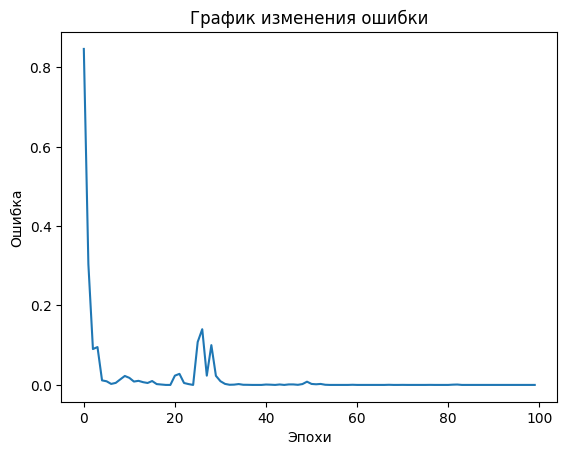

In [62]:
plt.plot(total_loss_train)
plt.title('График изменения ошибки')
plt.xlabel('Эпохи')
plt.ylabel('Ошибка')
plt.show()

In [63]:
MODEL_PATH = "user_pre_best_model.pth"       
VLAD_FACES_DIR = "dataset/original/Vlad" 
DB_FILE = "face_db.pt"

model = Encoder(device_str='cuda')
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])


vectors = []
files = os.listdir(VLAD_FACES_DIR)
print(f"Создаем эталон из {len(files)} фото...")

with torch.no_grad():
    for f in files:
        path = os.path.join(VLAD_FACES_DIR, f)
        img = Image.open(path).convert('RGB')
        tensor = transform(img).unsqueeze(0).to(device) 
        
        emb = model(tensor)
        vectors.append(emb)

if len(vectors) > 0:
    
    batch = torch.cat(vectors, dim=0)
    mean_vector = torch.mean(batch, dim=0, keepdim=True)
    final_vector = torch.nn.functional.normalize(mean_vector, p=2, dim=1)
    
    db = {"User": final_vector.cpu()}
    torch.save(db, DB_FILE)
    print(f"База {DB_FILE} успешно создана!")
else:
    print("Не найдено фото для создания базы.")

Создаем эталон из 59 фото...
База face_db.pt успешно создана!


In [ ]:
WEIGHTS_FILE = "user_pre_best_model.pth"
DB_FILE = "face_db.pt"
THRESHOLD = 0.8 

print("Загрузка модели...")
model = Encoder()
if os.path.exists(WEIGHTS_FILE):
    model.load_state_dict(torch.load(WEIGHTS_FILE))
model.eval()

if os.path.exists(DB_FILE):
    database = torch.load(DB_FILE)
    for name in database:
        database[name] = database[name].to(model.device)
else:
    print("База не найдена")
    exit()


cap = cv2.VideoCapture(0)
cap.set(3, 640)
cap.set(4, 480)

print("Камера работает (Haar Cascades). 'q' - выход.")

while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.flip(frame, 1)
    face_tensor, coords = model.preprocess_face_haar(frame)

    if face_tensor is not None:
        x, y, w, h = coords
        
        with torch.no_grad():
            current_vector = model(face_tensor)

        best_name = "Unknown"
        best_score = -1.0

        for name, db_vector in database.items():
            score = torch.mm(current_vector, db_vector.t()).item()
            if score > best_score:
                best_score = score
                best_name = name

        if best_score > THRESHOLD:
            color = (0, 255, 0)
            label = f"{best_name} ({best_score:.2f})"
        else:
            color = (0, 0, 255)
            label = f"Unknown ({best_score:.2f})"

        
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    cv2.imshow('Face ID ', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Загрузка модели...
Камера работает (Haar Cascades). 'q' - выход.
